## 載入套件

In [67]:
# 此區塊載入本次 PTT 留言情緒分析會用到的 Python 套件，包括：

# pandas：資料讀取與表格處理
# matplotlib：繪製情緒折線圖
# matplotlib.font_manager：指定中文字型避免圖表亂碼
# wordcloud：文字雲相關功能
# jieba：中文斷詞
# json：解析留言欄位中的 JSON 結構資料
# 此外，%matplotlib inline 讓圖表可以直接顯示在 Notebook 中。

import json
import ast
import html
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Colormap
from wordcloud import WordCloud
import jieba
import matplotlib.pyplot as plt
import re
import numpy as np

%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 取得資料
#### 智絢(df) -> ptt_wbc_all.csv (棒球、WBC、大型賽事版＋玩運彩版)
#### 卯郁(df_wbc) -> ptt_wbc.csv (棒球、WBC、大型賽事版)



In [68]:
# ================================================ #
# 2. 個別檔案讀取
# ================================================ #

# path_為運彩與WBC資料夾路徑
path = "/content/drive/MyDrive/中山大學/社群媒體分析/SMA_2024S-main/study_group_10/ProjectAnalysis1/Data/"

# df為運彩的dataframe
df = pd.read_csv(path + "ptt_wbc_all.csv") #智絢

# df_wbc 為WBC的dataframe
df_wbc = pd.read_csv(path + "ptt_wbc.csv") #卯郁


##　智絢專用篩選特定區間資料

In [36]:
# ================================================ #
# 3. 建立分析資料集並篩選指定時間範圍
# ================================================ #

# 此區塊先複製原始資料成為 df_zhixuan_filtered，避免直接修改原始資料表。

# 接著進行兩項前處理：

# 將 artDate 轉為 datetime 格式，方便做時間篩選
# 以指定時間點為中心，取前後 10 小時的文章資料作為分析範圍
# 同時移除本次情緒分析不需要的欄位，例如：

# artUrl
# artPoster
# e_ip
# 這一步的目的，是先縮小分析資料範圍並保留必要欄位。

# Define the list of games to analyze
games_to_analyze = [
    {"game_name": "台灣 vs 日本", "target_time": pd.Timestamp("2026-03-06 18:00:00")},
    {"game_name": "台灣 vs 澳洲", "target_time": pd.Timestamp("2026-03-05 11:00:00")},
    {"game_name": "台灣 vs 韓國", "target_time": pd.Timestamp("2026-03-08 11:00:00")}
]

# This block continues to create df_zhixuan_filtered for a default game (e.g., the first one)
# This is to ensure subsequent cells (like the call to process_dataframe in 25e19f6b)
# have df_zhixuan_filtered defined without errors, though it will be overwritten in the loop below.

df_zhixuan_filtered = df.copy()
df_zhixuan_filtered["artDate"] = pd.to_datetime(df_zhixuan_filtered["artDate"])

# Use the first game from the list as the default for initial setup
default_game_name = games_to_analyze[0]["game_name"]
default_target_time = games_to_analyze[0]["target_time"]
start_time = default_target_time - pd.Timedelta(hours=10)
end_time = default_target_time + pd.Timedelta(hours=10)

df_zhixuan_filtered = df_zhixuan_filtered[
    (df_zhixuan_filtered["artDate"] >= start_time) &
    (df_zhixuan_filtered["artDate"] <= end_time)
]


## 卯郁專用篩選特定區間資料

In [69]:
# 1. 複製資料並確保時間格式（不影響原始處理流程）
df_maoyu_filtered = df_wbc.copy()
df_maoyu_filtered["artDate"] = pd.to_datetime(df_maoyu_filtered["artDate"])

# 2. 定義 2026 WBC 時段
periods = {
    "pre_game":  (pd.Timestamp("2026-02-19 00:00:00"), pd.Timestamp("2026-03-04 23:59:59")),
    "mid_game":  (pd.Timestamp("2026-03-05 00:00:00"), pd.Timestamp("2026-03-09 23:59:59")),
    "post_game": (pd.Timestamp("2026-03-10 00:00:00"), pd.Timestamp("2026-03-17 23:59:59"))
}

# 3. 執行篩選
mask = (
    (df_maoyu_filtered["artDate"].between(periods["pre_game"][0],  periods["pre_game"][1])) |
    (df_maoyu_filtered["artDate"].between(periods["mid_game"][0],  periods["mid_game"][1])) |
    (df_maoyu_filtered["artDate"].between(periods["post_game"][0], periods["post_game"][1]))
)
df_maoyu_filtered = df_maoyu_filtered[mask].copy()

# 4. 新增標註時段欄位
def label_period(dt):
    if periods["pre_game"][0] <= dt <= periods["pre_game"][1]:
        return "賽前"
    elif periods["mid_game"][0] <= dt <= periods["mid_game"][1]:
        return "賽中"
    elif periods["post_game"][0] <= dt <= periods["post_game"][1]:
        return "賽後"
    else:
        return "其他"

df_maoyu_filtered["period_group"] = df_maoyu_filtered["artDate"].apply(label_period)

print(f"篩選後資料總筆數：{len(df_maoyu_filtered)}")
print(df_maoyu_filtered["period_group"].value_counts())

篩選後資料總筆數：7331
period_group
賽中    3128
賽後    2363
賽前    1840
Name: count, dtype: int64


### 曉君專用篩選特定區間資料(如果不用要註解掉)

In [38]:
# # 讀取檔案
# df_wbc = pd.read_csv(filename) # 'filename' is undefined, and df_wbc is already loaded.
# print("目前讀取檔案：", filename)
# clear_df = df_wbc.copy()

# # 轉換時間格式
# clear_df["artDate"] = pd.to_datetime(clear_df["artDate"], errors="coerce")

# # 移除無效時間
# clear_df = clear_df.dropna(subset=["artDate"])

# # 設定期間(C組競賽前後二週)
# start_time = pd.Timestamp("2026-02-19 00:00:00")
# end_time   = pd.Timestamp("2026-03-17 23:59:59")

# # 篩選
# clear_df = clear_df[
#     (clear_df["artDate"] >= start_time) &
#     (clear_df["artDate"] <= end_time)
# ].copy()


# # 檢查
# print(f"分析期間：{start_time} ~ {end_time}")
# print("篩選後資料筆數：", clear_df.shape)
# display(clear_df.head())

## 開始資料清理及文字處理

In [70]:
# ================================================ #
# 開始資料清理及文字處理 (Refactored into a function)
# ================================================ #

# ================================================ #
# 7. 初始化 jieba 中文斷詞與加入棒球自訂詞
# (Moved outside function to avoid re-initialization and define global paths)
# ================================================ #
BASE_DRIVE_PATH = "/content/drive/MyDrive/中山大學/社群媒體分析/SMA_2024S-main/"
DICT_PATH = BASE_DRIVE_PATH + "week4/dict/"
PROJECT_PATH = BASE_DRIVE_PATH + "study_group_10/ProjectAnalysis1/"
LIWC_PATH = DICT_PATH + "liwc/"

jieba.set_dictionary(DICT_PATH + "dict.txt")
jieba.load_userdict(DICT_PATH + "user_dict.txt")

CUSTOM_WORDS = sorted(set([
    "WBC", "WBCQ", "12強", "P12", "經典賽", "資格賽", "八強", "8強", "四強", "冠軍戰",
    "世界大賽", "小組賽", "複賽", "春訓",
    "MLB", "NPB", "KBO", "CPBL", "CPBLTV", "中職", "日職", "韓職", "大聯盟",
    "中華隊", "台灣隊", "日本隊", "韓國隊", "美國隊",
    "委內瑞拉", "多明尼加", "波多黎各", "義大利", "加拿大", "捷克", "澳洲", "巴拿馬", "墨西哥",
    "全壘打", "逆轉砲", "球數限制", "投手調度", "教練團",
    "牛棚", "先發", "中繼", "後援", "投手群", "打線", "長打", "短期賽",
    "大谷", "大谷翔平", "近藤", "近藤健介", "山本", "山本由伸",
    "達比修", "達比修有", "佐佐木", "佐佐木朗希", "朗希",
    "古林", "古林睿煬", "古琳", "徐若熙", "若熙", "若C",
    "王建民", "陳偉殷", "郭泓志", "曹錦輝", "張育成",
    "舒服", "戰犯", "崩潰", "笑死", "笑爛", "穩了", "不錯", "不行", "看不懂",
    "還不錯", "太棒", "很好用", "不能幸災樂禍", "不要幸災樂禍"
]))

for w in CUSTOM_WORDS:
    jieba.add_word(w, freq=300000)


def process_dataframe(input_df):
    df_processed = input_df.copy()

    # 去除不用的欄位
    drop_cols = ['artUrl', 'artPoster', 'e_ip']
    df_processed.drop(columns=drop_cols, axis=1, inplace=True, errors='ignore')

    # ================================================ #
    # 4. 解析留言欄位並展開成逐筆留言資料
    # ================================================ #

    def parse_comments(comment_text):
        if pd.isna(comment_text):
            return []
        text = str(comment_text).strip()
        if not text:
            return []
        try:
            data = ast.literal_eval(text)
            return data if isinstance(data, list) else []
        except:
            try:
                data = json.loads(text)
                return data if isinstance(data, list) else []
            except:
                return []

    rows = []
    for _, row in df_processed.iterrows():
        comments = parse_comments(row.get("artComment"))
        for c in comments:
            if not isinstance(c, dict):
                continue
            rows.append({
                "artTitle": row.get("artTitle"),
                "artDate": row.get("artDate"),
                "artCatagory": row.get("artCatagory"),
                "cmtStatus": c.get("cmtStatus"),
                "cmtContent": c.get("cmtContent"),
                "cmtDate": c.get("cmtDate"),
            })

    if not rows:
        print("Warning: No comments found after parsing for this dataframe.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame() # Return empty for all three

    clear_df_comments = pd.DataFrame(rows)

    clear_df_comments = clear_df_comments.dropna(subset=["cmtContent"]).copy()
    clear_df_comments["cmtContent"] = clear_df_comments["cmtContent"].astype(str).str.strip()
    clear_df_comments = clear_df_comments[clear_df_comments["cmtContent"] != ""].reset_index(drop=True)

    # ================================================ #
    # 5.統一文章時間與留言時間格式
    # ================================================ #
    def parse_to_taipei_datetime(series):
        return pd.to_datetime(series, errors="coerce")

    clear_df_comments["artDate"] = parse_to_taipei_datetime(clear_df_comments["artDate"])
    clear_df_comments["cmtDate"] = parse_to_taipei_datetime(clear_df_comments["cmtDate"])

    # ================================================ #
    # 6. 基本文字清理與主題過濾
    # ================================================ #
    def clean_text(text):
        text = str(text)
        text = re.sub(r"^[:：]+\s*", "", text)
        text = html.unescape(text)
        text = text.replace("\r", " ").replace("\n", " ").replace("\t", " ")
        text = re.sub(r"http\S+|www\.\S+", " ", text)
        replacements = {
            "．": ".", "＋": "+", "－": "-", "／": "/",
            "＃": "#", "：": ":", "％": "%",
        }
        for k, v in replacements.items():
            text = text.replace(k, v)
        text = re.sub(r"[，、；：「」『』（）()[\\]<>《》~…【】]", " ", text)
        text = re.sub(r"[。！？!?,]", " ", text)
        text = re.sub(r"\.{2,}", " ... ", text)
        text = re.sub(r"[^0-9A-Za-z一-龥\s\-\.\+/#:]", " ", text)
        text = re.sub(r"\s+", " ", str(text)).strip()
        return text

    artTitle_notWord = r"超|NBA|網球|電競|甲|乙|籃球|足球"
    clear_df_comments = clear_df_comments[~clear_df_comments["artTitle"].str.contains(artTitle_notWord, na=False)].copy()

    clear_df_comments["clean_text"] = clear_df_comments["cmtContent"].apply(clean_text)
    clear_df_comments = clear_df_comments[clear_df_comments["clean_text"].str.strip() != ""].copy()

    # ================================================ #
    # 7. 初始化 jieba 中文斷詞與加入棒球自訂詞 (moved to the top level to avoid re-init)
    # ================================================ #

    # ================================================ #
    # 9. 中文斷詞與雙詞合併處理
    # ================================================ #
    def tokenize_raw(text):
        raw_tokens = jieba.lcut(text)
        merged = []
        i = 0
        units = {"球", "局", "壘", "分", "顆", "次", "勝", "敗", "樓", "年", "歲", "月", "日", "周", "週", "強", "倍", "轟", "安打"}
        two_word_merge = {
            ("投手", "調度"): "投手調度", ("教練", "團"): "教練團", ("球數", "限制"): "球數限制",
            ("世界", "大賽"): "世界大賽", ("冠軍", "戰"): "冠軍戰", ("台灣", "隊"): "台灣隊",
            ("中華", "隊"): "中華隊", ("日本", "隊"): "日本隊", ("韓國", "隊"): "韓國隊",
            ("美國", "隊"): "美國隊", ("委內", "瑞拉"): "委內瑞拉", ("多明", "尼加"): "多明尼加",
            ("波多", "黎各"): "波多黎各", ("打", "爆"): "打爆", ("打", "贏"): "打贏",
            ("被", "淘汰"): "被淘汰", ("回去", "春訓"): "回去春訓", ("最大", "贏家"): "最大贏家",
            ("菜雞", "組"): "菜雞組", ("信任", "野球"): "信任野球", ("志在", "參加"): "志在參加",
            ("一輪", "遊"): "一輪遊", ("死亡", "之組"): "死亡之組", ("安定", "感"): "安定感",
            ("比較", "強"): "比較強", ("看", "不懂"): "看不懂", ("還", "不錯"): "還不錯",
            ("很", "方便"): "很方便", ("太", "棒"): "太棒", ("意義", "在哪"): "意義在哪",
            ("關鍵", "球員"): "關鍵球員", ("幸災", "樂禍"): "幸災樂禍", ("原", "PO"): "原PO",
        }
        while i < len(raw_tokens):
            t1 = raw_tokens[i].strip()
            t2 = raw_tokens[i + 1].strip() if i < len(raw_tokens) - 1 else ""
            t3 = raw_tokens[i + 2].strip() if i < len(raw_tokens) - 2 else ""
            if not t1:
                i += 1
                continue
            if t2 == "-" and t3 and re.match(r"^\d+(\.\d+)?$", t1) and re.match(r"^\d+(\.\d+)?$", t3):
                merged.append(f"{t1}-{t3}")
                i += 3
                continue
            if t2 and re.match(r"^\d+(\.\d+)?$", t1) and t2 in units:
                merged.append(t1 + t2)
                i += 2
                continue
            if (t1, t2) in two_word_merge:
                merged.append(two_word_merge[(t1, t2)])
                i += 2
                continue
            if t1 == "MLB" and t2 == "TV":
                merged.append("MLBTV")
                i += 2
                continue
            if t1 == "CPBL" and t2 == "TV":
                merged.append("CPBLTV")
                i += 2
                continue
            if t1 == "若" and t2 == "C":
                merged.append("若C")
                i += 2
                continue
            merged.append(t1)
            i += 1
        return [t for t in merged if t and not t.isspace()]

    clear_df_comments["tokens_raw"] = clear_df_comments["clean_text"].apply(tokenize_raw)

    # ================================================ #
    # 10. 否定詞與情緒短語合併
    # ================================================ #
    NEGATION_WORDS = {"不", "沒", "無", "別", "莫", "非"}
    NEGATION_COMPOUNDS = {
        "不錯", "不好", "不行", "不強", "不穩", "不妙", "不爽", "不爛", "不弱",
        "沒差", "沒救", "沒用", "沒戲", "沒招", "沒力", "沒辦法",
        "無聊", "無言", "無解",
        "不要", "不能", "不是"
    }
    THREE_WORD_COMPOUNDS = {
        ("不", "太", "行"): "不太行", ("不", "太", "穩"): "不太穩", ("不", "太", "好"): "不太好",
        ("不", "太", "妙"): "不太妙", ("不", "太", "差"): "不太差", ("沒", "什麼", "差"): "沒什麼差",
    }
    def merge_sentiment_phrases(tokens):
        merged = []
        i = 0
        n = len(tokens)
        while i < n:
            t1 = str(tokens[i]).strip()
            t2 = str(tokens[i + 1]).strip() if i + 1 < n else ""
            t3 = str(tokens[i + 2]).strip() if i + 2 < n else ""
            if not t1:
                i += 1
                continue
            if (t1, t2, t3) in THREE_WORD_COMPOUNDS:
                merged.append(THREE_WORD_COMPOUNDS[(t1, t2, t3)])
                i += 3
                continue
            if t1 in NEGATION_WORDS and t2:
                candidate = t1 + t2
                if candidate in NEGATION_COMPOUNDS:
                    merged.append(candidate)
                    i += 2
                    continue
            merged.append(t1)
            i += 1
        return merged

    clear_df_comments["tokens_phrase_merged"] = clear_df_comments["tokens_raw"].apply(merge_sentiment_phrases)

    # ================================================ #
    # 11. 語意標準化與同義詞整併
    # ================================================ #
    TOKEN_CANONICAL_MAP = {
        "若C": "徐若熙", "若熙": "徐若熙", "徐": "徐若熙", "古琳": "古林",
        "古林睿煬": "古林", "大谷翔平": "大谷", "近藤健介": "近藤", "山本由伸": "山本",
        "達比修有": "達比修", "佐佐木朗希": "朗希", "還不錯": "不錯", "不太差": "不錯",
        "不太好": "不好", "不太行": "不行", "不太穩": "不穩", "不太妙": "不妙",
    }
    def semantic_normalize_tokens(tokens):
        return [TOKEN_CANONICAL_MAP.get(t, t) for t in tokens]

    clear_df_comments["tokens_semantic"] = clear_df_comments["tokens_phrase_merged"].apply(semantic_normalize_tokens)

    # ================================================ #
    # 12. 讀取停用字清單、補充停用字與中性詞彙
    # ================================================ #
    stopwords = [line.strip() for line in open(DICT_PATH + 'stopwords.txt', 'r', encoding='utf-8').readlines()]
    stopwords_manual = [
        "直接", "iPhone", "知道", "Ptt", "JPTT", "今天", "看到", "這場",
        "還是", "可以", "真的", "沒有", "我們", "from", "Sent", "應該",
        "on", "my", "這樣", "如果", "現在"
    ]
    STOPWORDS = set(stopwords + stopwords_manual + [
        "的", "了", "啊", "吧", "喔", "嗎", "呢", "啦", "欸",
        "是", "也", "都", "就", "很", "還", "又", "在", "有",
        "我", "你", "他", "她", "它", "我們", "你們", "他們",
        "這", "那", "而且", "所以", "但是", "然後",
        "一個", "一些", "一下", "真的", "可能", "覺得", "就是",
        "不是", "沒有", "其實", "這次", "上次", "今天", "現在",
        "已經", "只是", "還是", "一堆", "完全", "這樣", "那樣",
        "而已", "而是", "比較", "非常", "一直",
        "來", "去", "被", "讓", "跟", "和", "與", "對", "把",
        "XD", "QQ", "...", "哈", "哈哈", "哈哈哈", "www", "wwww",
        "好", "大"
    ])
    EMOTION_NEUTRAL_WORDS = {
        "打", "打者", "打擊", "打線", "投手", "投手群", "牛棚", "先發", "中繼", "後援",
        "守備", "棒次", "球員", "球數", "球速", "安打", "全壘打", "失誤", "暴投", "盜壘",
        "大聯盟", "中華隊", "台灣隊", "日本隊", "韓國隊", "美國隊"
    }
    def filter_tokens(tokens):
        result = []
        for t in tokens:
            t = str(t).strip()
            if not t: continue
            if t in STOPWORDS: continue
            if t in EMOTION_NEUTRAL_WORDS: continue
            if re.fullmatch(r"[-\./#:]+", t): continue
            if len(t) == 1 and re.fullmatch(r"[A-Za-z]", t): continue
            if t in {"不", "沒", "無"}: continue
            result.append(t)
        return result

    clear_df_comments["tokens_filtered"] = clear_df_comments["tokens_semantic"].apply(filter_tokens)

    # ================================================ #
    # 13. 轉換為逐詞資料表並建立分析用資料集
    # ================================================ #
    clear_df_comments["processed_text"] = clear_df_comments["tokens_filtered"].apply(
        lambda x: " ".join(x) if isinstance(x, list) else ""
    )
    word_df = clear_df_comments[[
        "artTitle", "artDate", "artCatagory", "cmtStatus", "cmtDate", "cmtContent", "tokens_filtered", "processed_text"
    ]].explode("tokens_filtered").rename(columns={"tokens_filtered": "word"})
    word_df["word"] = word_df["word"].astype(str).str.strip()
    word_df = word_df[word_df["word"] != ""].copy()

    noStop_df = word_df.copy()

    # ================================================ #
    # 14. 建立欄位橋接（留言內容與分析日期）
    # ================================================ #
    noStop_df = noStop_df.rename(columns={
        "cmtDate": "commentDate",
        "cmtContent": "artContent"
    })
    noStop_df["analysisDate"] = noStop_df["commentDate"].fillna(noStop_df["artDate"])

    # ================================================ #
    # 15. 依看板主題切分為棒球版與運彩版資料集
    # ================================================ #
    mask = noStop_df['artCatagory'].str.contains(r"棒球|MLB|大型賽事", na=False)
    noStop_wbc_df = noStop_df[mask].copy()
    noStop_lottery_df = noStop_df[~mask].copy()

    for temp_df in [noStop_wbc_df, noStop_lottery_df]:
        temp_df.rename(columns={
            "cmtContent": "artContent",
            "cmtDate": "commentDate"
        }, inplace=True)
        temp_df["artDate"] = temp_df["commentDate"].fillna(temp_df["artDate"])

    return clear_df_comments, noStop_wbc_df, noStop_lottery_df

# ================================================ #
# 執行資料處理流程 for 智絢 and 卯郁
# ================================================ #
print("Processing 智絢's data...")
zhixuan_full_comments_df, noStop_zhixuan_wbc_df, noStop_zhixuan_lottery_df = process_dataframe(df_zhixuan_filtered)
print("Processing 卯郁's data...")
maoyu_full_comments_df, noStop_maoyu_wbc_df, noStop_maoyu_lottery_df = process_dataframe(df_maoyu_filtered)

# ================================================ #
# 選擇要分析的資料來源
# ================================================ #
DATA_SOURCE = "zhixuan" # 可以改成 "maoyu" 來分析卯郁的資料

if DATA_SOURCE == "zhixuan":
    print("Using 智絢's data for analysis.")
    noStop_wbc_df = noStop_zhixuan_wbc_df
    noStop_lottery_df = noStop_zhixuan_lottery_df
    maoyu_analysis_df = zhixuan_full_comments_df # Used for 卯郁's analysis module (cell 5U9bcOXqCMb5)
elif DATA_SOURCE == "maoyu":
    print("Using 卯郁's data for analysis.")
    noStop_wbc_df = noStop_maoyu_wbc_df
    noStop_lottery_df = noStop_maoyu_lottery_df
    maoyu_analysis_df = maoyu_full_comments_df # Used for 卯郁's analysis module (cell 5U9bcOXqCMb5)
else:
    raise ValueError("Invalid DATA_SOURCE. Must be 'zhixuan' or 'maoyu'.")

print("\nnoStop_wbc_df head:")
display(noStop_wbc_df.head())
print("\nnoStop_lottery_df head:")
display(noStop_lottery_df.head())

Building prefix dict from /content/drive/MyDrive/中山大學/社群媒體分析/SMA_2024S-main/week4/dict/dict.txt ...
DEBUG:jieba:Building prefix dict from /content/drive/MyDrive/中山大學/社群媒體分析/SMA_2024S-main/week4/dict/dict.txt ...
Loading model from cache /tmp/jieba.ufa65c5ea14c722dbb7227fffcc93ec89.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.ufa65c5ea14c722dbb7227fffcc93ec89.cache
Loading model cost 0.947 seconds.
DEBUG:jieba:Loading model cost 0.947 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


Processing 智絢's data...
Processing 卯郁's data...
Using 智絢's data for analysis.

noStop_wbc_df head:


,artTitle,artDate,artCatagory,cmtStatus,commentDate,artContent,word,processed_text,analysisDate
0,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,2026-03-06 08:02:00+08:00,棒球,推,2026-03-06 08:02:00+08:00,: 然後再輸CT對吧,再輸,再輸 CT,2026-03-06 08:02:00+08:00
0,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,2026-03-06 08:02:00+08:00,棒球,推,2026-03-06 08:02:00+08:00,: 然後再輸CT對吧,CT,再輸 CT,2026-03-06 08:02:00+08:00
1,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,2026-03-06 08:02:00+08:00,棒球,推,2026-03-06 08:02:00+08:00,: 第一場翻車，被人家嘴秋怪誰呢,場,場 翻車 嘴秋怪,2026-03-06 08:02:00+08:00
1,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,2026-03-06 08:02:00+08:00,棒球,推,2026-03-06 08:02:00+08:00,: 第一場翻車，被人家嘴秋怪誰呢,翻車,場 翻車 嘴秋怪,2026-03-06 08:02:00+08:00
1,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,2026-03-06 08:02:00+08:00,棒球,推,2026-03-06 08:02:00+08:00,: 第一場翻車，被人家嘴秋怪誰呢,嘴秋怪,場 翻車 嘴秋怪,2026-03-06 08:02:00+08:00



noStop_lottery_df head:


,artTitle,artDate,artCatagory,cmtStatus,commentDate,artContent,word,processed_text,analysisDate
60188,[推薦] 棒球 馬克土司看經典賽,2026-03-06 09:05:00+08:00,SportLottery,推,2026-03-06 09:05:00+08:00,: 推,推,推,2026-03-06 09:05:00+08:00
60189,[推薦] 棒球 馬克土司看經典賽,2026-03-06 09:10:00+08:00,SportLottery,推,2026-03-06 09:10:00+08:00,: 同路 看好早場大 晚場中華小,同路,同路 看好 早場 晚場 中華,2026-03-06 09:10:00+08:00
60189,[推薦] 棒球 馬克土司看經典賽,2026-03-06 09:10:00+08:00,SportLottery,推,2026-03-06 09:10:00+08:00,: 同路 看好早場大 晚場中華小,看好,同路 看好 早場 晚場 中華,2026-03-06 09:10:00+08:00
60189,[推薦] 棒球 馬克土司看經典賽,2026-03-06 09:10:00+08:00,SportLottery,推,2026-03-06 09:10:00+08:00,: 同路 看好早場大 晚場中華小,早場,同路 看好 早場 晚場 中華,2026-03-06 09:10:00+08:00
60189,[推薦] 棒球 馬克土司看經典賽,2026-03-06 09:10:00+08:00,SportLottery,推,2026-03-06 09:10:00+08:00,: 同路 看好早場大 晚場中華小,晚場,同路 看好 早場 晚場 中華,2026-03-06 09:10:00+08:00


In [71]:
# ================================================ #
# 17. 載入並補強情緒字典
# ================================================ #

# 此區塊會：

# 載入正面詞與負面詞檔案
# 移除部分容易誤判的詞
# 補充與棒球討論情境較相關的自訂情緒詞
# 清理正負詞重疊項
# 與 LIWC 字典合併，形成最終的情緒詞典 liwc_dict
# 這一步的目的，是讓情緒分析除了依賴原始 LIWC 外，也能更貼近棒球／PTT 語境。

def load_sentiment_words(file_path):
    words = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            w = line.strip()
            if w:
                words.append(w)
    return sorted(set(words))

POS_PATH = PROJECT_PATH + "正面詞_融合去重整理_utf8.txt"
NEG_PATH = PROJECT_PATH + "負面詞_融合去重整理_utf8.txt"

positive_words = load_sentiment_words(POS_PATH)
negative_words = load_sentiment_words(NEG_PATH)

positive_remove = {"還", "行", "重要", "不同", "對不起", "大事", "深入", "公開", "自然", "老師", "美美", "統一", "DP", "BB"}
negative_remove = {"現實", "圖", "手法", "打算", "大舉", "公然", "暫時", "施展", "反攻", "繼承者"}

positive_words = sorted(set(positive_words) - positive_remove)
negative_words = sorted(set(negative_words) - negative_remove)

extra_positive = {"穩", "穩了", "猛", "神", "扛", "關鍵", "精彩", "舒服", "有料", "夠強", "超強", "頂", "讚", "厲害", "贏球", "封鎖", "守住", "好球"}
extra_negative = {"雷", "爛", "炸裂", "烙賽", "崩", "抖", "失常", "可惜", "送頭", "自爆", "被打爆", "戰犯", "亂搞", "低級失誤", "崩盤", "慘", "廢", "不行"}

positive_words = sorted(set(positive_words) | extra_positive)
negative_words = sorted(set(negative_words) | extra_negative)

overlap_words = set(positive_words) & set(negative_words)
positive_words = sorted(set(positive_words) - overlap_words)
negative_words = sorted(set(negative_words) - overlap_words)

pos_df = pd.DataFrame({"word": positive_words, "sentiments": "positive"})
neg_df = pd.DataFrame({"word": negative_words, "sentiments": "negative"})
custom_sentiment_dict = pd.concat([pos_df, neg_df], ignore_index=True)

liwc_dict = pd.read_csv(LIWC_PATH + "LIWC_CH.csv")
liwc_dict = liwc_dict.rename(columns={"name": "word", "class": "sentiments"})

liwc_dict = pd.concat([liwc_dict[["word", "sentiments"]], custom_sentiment_dict], ignore_index=True)
liwc_dict = liwc_dict.drop_duplicates(subset=["word"], keep="first")

print("liwc_dict head:")
display(liwc_dict.head())

liwc_dict head:


,word,sentiments
0,):,affect
1,3q,affect
2,:(,affect
3,:),affect
4,<3,affect


## Team Taiwan vs. Team Money 情緒分析模組


--- Starting analysis for: 台灣 vs 日本 (Target Time: 2026-03-06 18:00:00) ---

ptt_wbc_liwc_df for 台灣 vs 日本 head:


,artDate,artTitle,artContent,word,sentiments
0,2026-03-06 08:02:00+08:00,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,: 然後再輸CT對吧,再輸,NaN
1,2026-03-06 08:02:00+08:00,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,: 然後再輸CT對吧,CT,NaN
2,2026-03-06 08:02:00+08:00,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,: 第一場翻車，被人家嘴秋怪誰呢,場,NaN
3,2026-03-06 08:02:00+08:00,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,: 第一場翻車，被人家嘴秋怪誰呢,翻車,negative
4,2026-03-06 08:02:00+08:00,[新聞] 中華隊熄火遭澳洲爆冷完封 韓媒酸台媒「,: 第一場翻車，被人家嘴秋怪誰呢,嘴秋怪,NaN



ptt_lottery_liwc_df for 台灣 vs 日本 head:


,artDate,artTitle,artContent,word,sentiments
0,2026-03-06 09:05:00+08:00,[推薦] 棒球 馬克土司看經典賽,: 推,推,NaN
1,2026-03-06 09:10:00+08:00,[推薦] 棒球 馬克土司看經典賽,: 同路 看好早場大 晚場中華小,同路,NaN
2,2026-03-06 09:10:00+08:00,[推薦] 棒球 馬克土司看經典賽,: 同路 看好早場大 晚場中華小,看好,NaN
3,2026-03-06 09:10:00+08:00,[推薦] 棒球 馬克土司看經典賽,: 同路 看好早場大 晚場中華小,早場,NaN
4,2026-03-06 09:10:00+08:00,[推薦] 棒球 馬克土司看經典賽,: 同路 看好早場大 晚場中華小,晚場,NaN


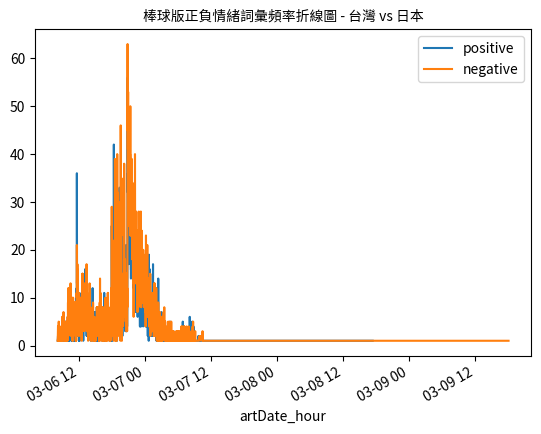

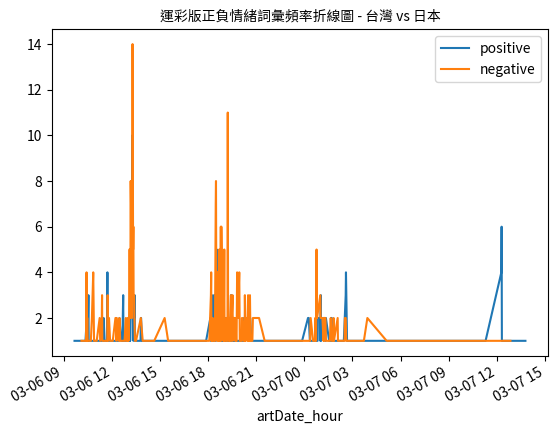

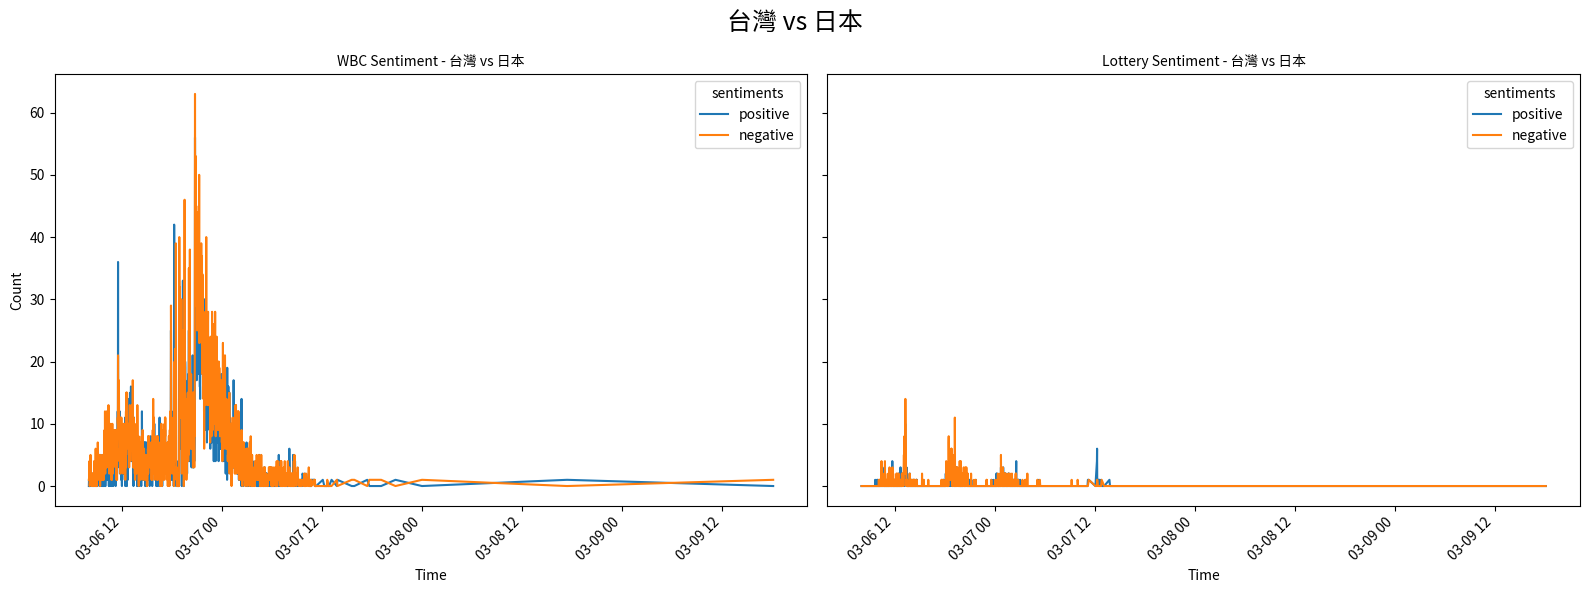


--- Starting analysis for: 台灣 vs 澳洲 (Target Time: 2026-03-05 11:00:00) ---

ptt_wbc_liwc_df for 台灣 vs 澳洲 head:


,artDate,artTitle,artContent,word,sentiments
0,2026-03-05 01:08:00+08:00,[情報] Hunter Greene手肘不適,: 要TJ了嗎…,TJ,NaN
1,2026-03-05 01:10:00+08:00,[情報] Hunter Greene手肘不適,: 火球男的宿命嗎…,火球,NaN
2,2026-03-05 01:10:00+08:00,[情報] Hunter Greene手肘不適,: 火球男的宿命嗎…,男,NaN
3,2026-03-05 01:10:00+08:00,[情報] Hunter Greene手肘不適,: 火球男的宿命嗎…,宿命,negative
4,2026-03-05 01:11:00+08:00,[情報] Hunter Greene手肘不適,: 又,nan,NaN



ptt_lottery_liwc_df for 台灣 vs 澳洲 head:


,artDate,artTitle,artContent,word,sentiments
0,2026-03-05 05:49:00+08:00,[推薦] 棒球「天九牌」經典賽冠軍,: 推,推,NaN
1,2026-03-05 06:20:00+08:00,[推薦] 棒球「天九牌」經典賽冠軍,: 怕,nan,NaN
2,2026-03-05 06:20:00+08:00,[推薦] 棒球「天九牌」經典賽冠軍,: 8強開始都壓日本，賠率應該比較好,8強,NaN
3,2026-03-05 06:20:00+08:00,[推薦] 棒球「天九牌」經典賽冠軍,: 8強開始都壓日本，賠率應該比較好,壓,NaN
4,2026-03-05 06:20:00+08:00,[推薦] 棒球「天九牌」經典賽冠軍,: 8強開始都壓日本，賠率應該比較好,日本,NaN


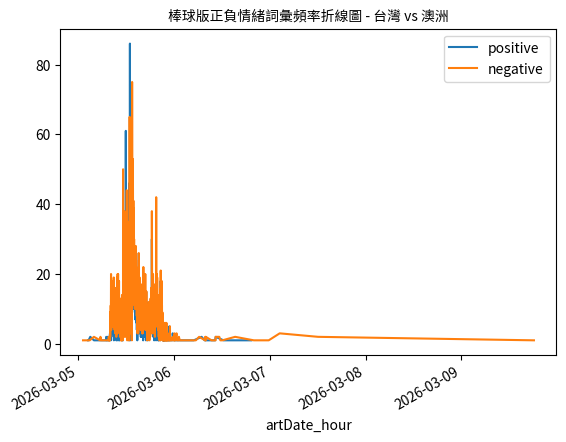

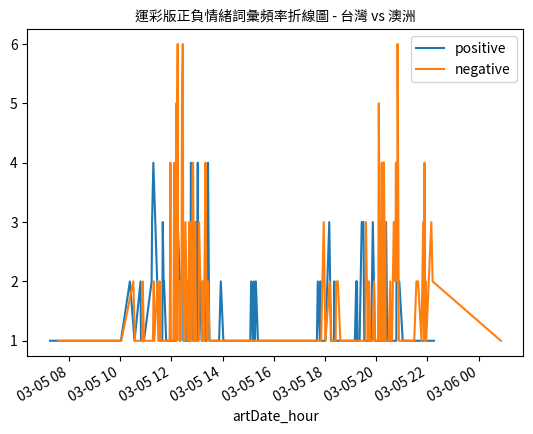

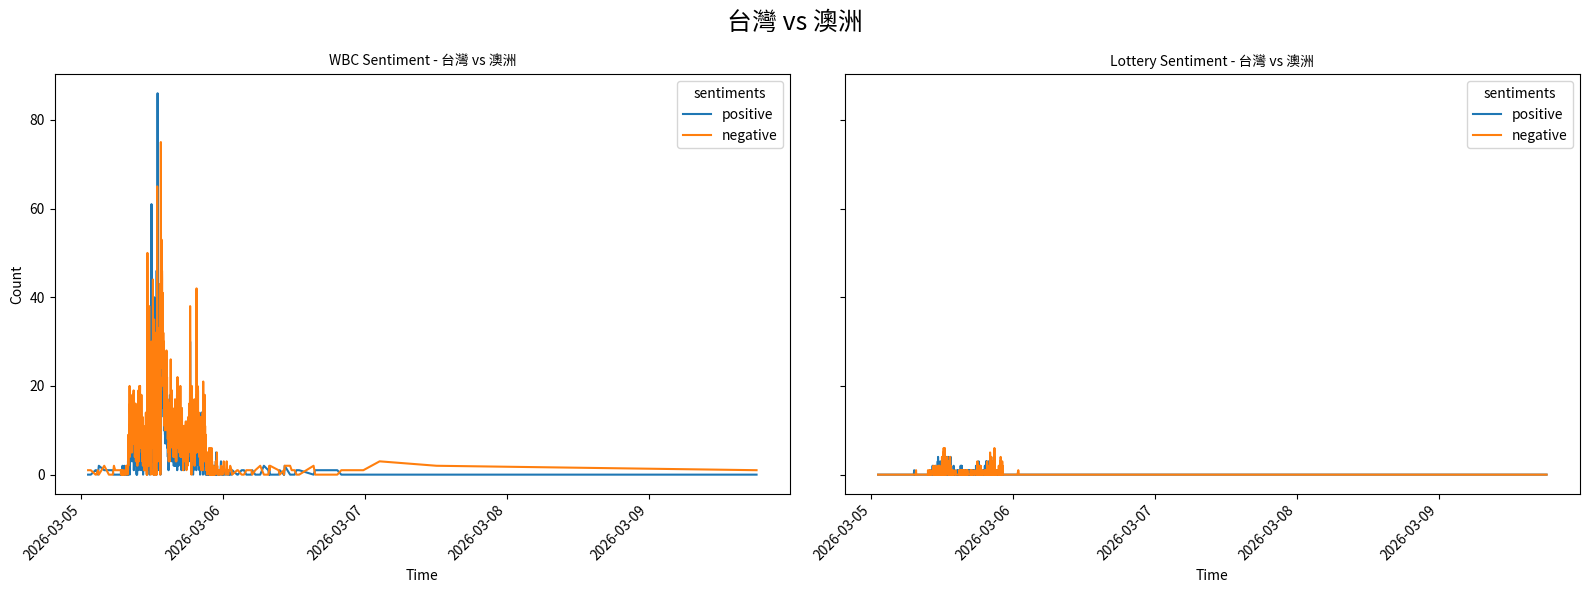


--- Starting analysis for: 台灣 vs 韓國 (Target Time: 2026-03-08 11:00:00) ---

ptt_wbc_liwc_df for 台灣 vs 韓國 head:


,artDate,artTitle,artContent,word,sentiments
0,2026-03-08 01:02:00+08:00,[LIVE] WBC2026 尼加拉瓜vs 荷蘭 Ｄ組 Game３,: 尼加拉瓜最有機會開胡的一場,尼加拉瓜,NaN
1,2026-03-08 01:02:00+08:00,[LIVE] WBC2026 尼加拉瓜vs 荷蘭 Ｄ組 Game３,: 尼加拉瓜最有機會開胡的一場,機會,positive
2,2026-03-08 01:02:00+08:00,[LIVE] WBC2026 尼加拉瓜vs 荷蘭 Ｄ組 Game３,: 尼加拉瓜最有機會開胡的一場,開胡,NaN
3,2026-03-08 01:02:00+08:00,[LIVE] WBC2026 尼加拉瓜vs 荷蘭 Ｄ組 Game３,: 尼加拉瓜最有機會開胡的一場,一場,NaN
4,2026-03-08 01:05:00+08:00,[LIVE] WBC2026 尼加拉瓜vs 荷蘭 Ｄ組 Game３,: 這場還是加拿大哥倫比亞會比較好看？,加拿大,NaN



ptt_lottery_liwc_df for 台灣 vs 韓國 head:


,artDate,artTitle,artContent,word,sentiments
0,2026-03-08 04:35:00+08:00,[LIVE] MLS 奧蘭多城 @ 紐約城,: 上三偷佛場,上三偷,NaN
1,2026-03-08 04:35:00+08:00,[LIVE] MLS 奧蘭多城 @ 紐約城,: 上三偷佛場,佛場,NaN
2,2026-03-08 05:20:00+08:00,[LIVE] MLS 奧蘭多城 @ 紐約城,: 666,666,NaN
3,2026-03-08 05:21:00+08:00,[LIVE] MLS 奧蘭多城 @ 紐約城,: 退,退,NaN
4,2026-03-08 05:28:00+08:00,[LIVE] MLS 奧蘭多城 @ 紐約城,: 不給面子球,面子,NaN


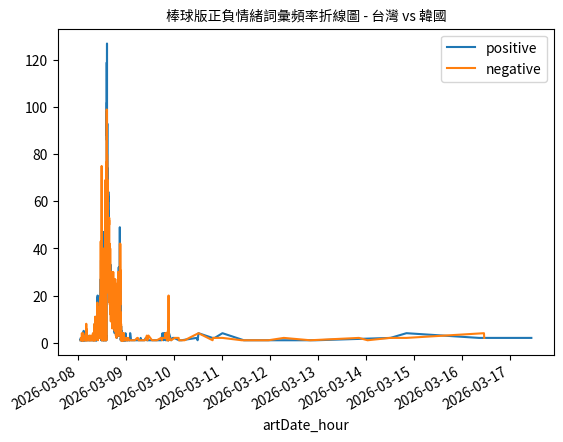

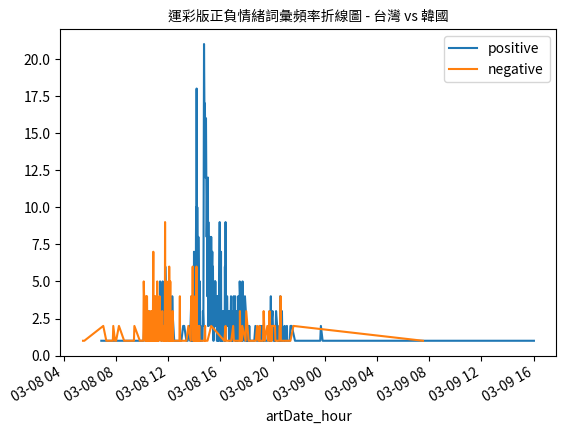

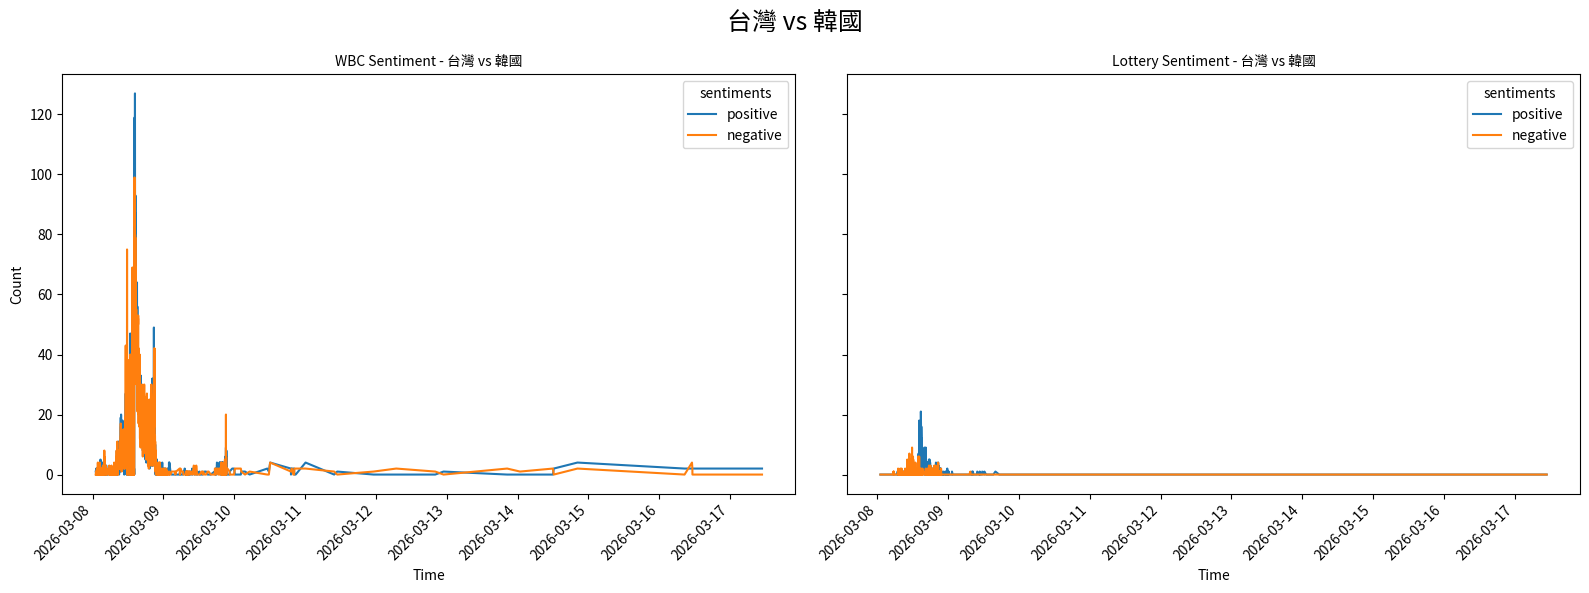


All game-specific sentiment analyses complete.


In [41]:
# ================================================ #
# 18. 合併棒球版資料與情緒字典
# ================================================ #

# 此區塊將棒球版逐詞資料 noStop_wbc_df 與情緒字典 liwc_dict 進行合併。
# 合併後可得到每個詞對應的情緒分類，形成 ptt_wbc_liwc_df，作為棒球版後續情緒統計的基礎資料表。

# ================================================ #
# 19. 合併運彩版資料與情緒字典
# ================================================ #

# 此區塊將運彩版逐詞資料 noStop_lottery_df 與情緒字典 liwc_dict 進行合併。
# 合併後形成 ptt_lottery_liwc_df，作為運彩版後續情緒統計與時間序列分析的基礎資料表。

# ================================================ #
# 20. 統計棒球版正負情緒詞的時間分布
# ================================================ #

# 此區塊針對棒球版資料：
# 將分析時間轉為 datetime
# 依時間與情緒分類分組
# 統計每個時間點的情緒詞數量
# 僅保留 positive 與 negative 兩類
# 最後產生 sentiment_wbc_count，供後續繪製棒球版情緒折線圖使用。

# ================================================ #
# 21. 統計運彩版正負情緒詞的時間分布
# ================================================ #

# ================================================ #
# 22. 繪製棒球版正負情緒折線圖
# ================================================ #

# ================================================ #
# 23. 繪製運彩版正負情緒折線圖
# ================================================ #

# ================================================ #
# 24. 建立棒球版與運彩版的並排情緒比較圖
# ================================================ #

path = "/content/drive/MyDrive/中山大學/社群媒體分析/SMA_2024S-main/week4/"

fprop = fm.FontProperties(fname= path +"SourceHanSansTW-Regular.otf")

# Loop through each game to perform analysis
for game_info in games_to_analyze:
    game_name = game_info["game_name"]
    target_time = game_info["target_time"]

    print(f"\n--- Starting analysis for: {game_name} (Target Time: {target_time}) ---")

    # --- Re-filter df for the current game (similar to WJdPihrBVj0J logic) ---
    # Use the original 'df' here to ensure each game analysis starts with the full dataset
    df_zhixuan_filtered_current_game = df.copy()
    df_zhixuan_filtered_current_game["artDate"] = pd.to_datetime(df_zhixuan_filtered_current_game["artDate"])

    start_time = target_time - pd.Timedelta(hours=10)
    end_time = target_time + pd.Timedelta(hours=10)

    df_zhixuan_filtered_current_game = df_zhixuan_filtered_current_game[
        (df_zhixuan_filtered_current_game["artDate"] >= start_time) &
        (df_zhixuan_filtered_current_game["artDate"] <= end_time)
    ]
    if df_zhixuan_filtered_current_game.empty:
        print(f"Warning: No data found for {game_name} within the specified time window. Skipping analysis for this game.")
        continue

    # --- Re-process the dataframe for the current game ---
    # Call the process_dataframe function from cell 25e19f6b
    zhixuan_full_comments_df_current_game, noStop_zhixuan_wbc_df_current_game, noStop_zhixuan_lottery_df_current_game = \
        process_dataframe(df_zhixuan_filtered_current_game)

    # --- Assign to general dataframes for consistency (mimicking 25e19f6b's final assignment) ---
    # This ensures noStop_wbc_df and noStop_lottery_df refer to the current game's data
    noStop_wbc_df = noStop_zhixuan_wbc_df_current_game
    noStop_lottery_df = noStop_zhixuan_lottery_df_current_game
    maoyu_analysis_df = zhixuan_full_comments_df_current_game # if '卯郁' module needs it

    # ================================================ #
    # 18. 合併棒球版資料與情緒字典
    # ================================================ #
    ptt_wbc_liwc_df = pd.merge(noStop_wbc_df[["artDate", "artTitle", "artContent", "word"]], liwc_dict, how="left")
    print(f"\nptt_wbc_liwc_df for {game_name} head:")
    display(ptt_wbc_liwc_df.head())

    # ================================================ #
    # 19. 合併運彩版資料與情緒字典
    # ================================================ #
    ptt_lottery_liwc_df = pd.merge(noStop_lottery_df[["artDate", "artTitle", "artContent", "word"]], liwc_dict, how="left")
    print(f"\nptt_lottery_liwc_df for {game_name} head:")
    display(ptt_lottery_liwc_df.head())

    # ================================================ #
    # 20. 統計棒球版正負情緒詞的時間分布
    # ================================================ #
    ptt_wbc_liwc_df['artDate_hour'] = pd.to_datetime(ptt_wbc_liwc_df['artDate'])
    sentiment_wbc_count = pd.DataFrame(
        ptt_wbc_liwc_df.groupby(["artDate_hour", "sentiments"]).size()
    ).reset_index()
    mask = (sentiment_wbc_count['sentiments'] == "positive") | (sentiment_wbc_count['sentiments'] == "negative")
    sentiment_wbc_count = sentiment_wbc_count.loc[mask]
    sentiment_wbc_count = sentiment_wbc_count.rename(columns={0: "size"})
    sentiment_wbc_count = sentiment_wbc_count.sort_values(["artDate_hour"])

    # ================================================ #
    # 21. 統計運彩版正負情緒詞的時間分布
    # ================================================ #
    ptt_lottery_liwc_df['artDate_hour'] = pd.to_datetime(ptt_lottery_liwc_df['artDate'])
    sentiment_lottery_count = pd.DataFrame(
        ptt_lottery_liwc_df.groupby(["artDate_hour", "sentiments"]).size()
    ).reset_index()
    mask = (sentiment_lottery_count['sentiments'] == "positive") | (sentiment_lottery_count['sentiments'] == "negative")
    sentiment_lottery_count = sentiment_lottery_count.loc[mask]
    sentiment_lottery_count = sentiment_lottery_count.rename(columns={0: "size"})
    sentiment_lottery_count = sentiment_lottery_count.sort_values(["artDate_hour"])

    # ================================================ #
    # 22. 繪製棒球版正負情緒折線圖
    # ================================================ #
    colors = ["tab:blue", "tab:orange"]
    pos = sentiment_wbc_count[sentiment_wbc_count["sentiments"] == "positive"]
    neg = sentiment_wbc_count[sentiment_wbc_count["sentiments"] == "negative"]

    fig, ax = plt.subplots()
    ax.plot(pos["artDate_hour"], pos["size"], color=colors[0])
    ax.plot(neg["artDate_hour"], neg["size"], color=colors[1])
    plt.xlabel("artDate_hour")
    ax.legend(["positive", "negative"], loc="upper right")
    fig.autofmt_xdate()
    plt.title(f"棒球版正負情緒詞彙頻率折線圖 - {game_name}", fontproperties=fprop)
    plt.show()

    # ================================================ #
    # 23. 繪製運彩版正負情緒折線圖
    # ================================================ #
    pos = sentiment_lottery_count[sentiment_lottery_count["sentiments"] == "positive"]
    neg = sentiment_lottery_count[sentiment_lottery_count["sentiments"] == "negative"]

    fig, ax = plt.subplots()
    ax.plot(pos["artDate_hour"], pos["size"], color=colors[0])
    ax.plot(neg["artDate_hour"], neg["size"], color=colors[1])
    plt.xlabel("artDate_hour")
    ax.legend(["positive", "negative"], loc="upper right")
    fig.autofmt_xdate()
    plt.title(f"運彩版正負情緒詞彙頻率折線圖 - {game_name}", fontproperties=fprop)
    plt.show()

    # ================================================ #
    # 24. 建立棒球版與運彩版的並排情緒比較圖
    # ================================================ #
    sentiment_wbc_count['artDate_hour'] = pd.to_datetime(sentiment_wbc_count['artDate_hour'])
    sentiment_lottery_count['artDate_hour'] = pd.to_datetime(sentiment_lottery_count['artDate_hour'])

    all_time = sorted(
        set(sentiment_wbc_count['artDate_hour']).union(set(sentiment_lottery_count['artDate_hour']))
    )

    wbc_pivot = sentiment_wbc_count.pivot(
        index='artDate_hour', columns='sentiments', values='size'
    ).reindex(all_time).fillna(0)

    lottery_pivot = sentiment_lottery_count.pivot(
        index='artDate_hour', columns='sentiments', values='size'
    ).reindex(all_time).fillna(0)

    # Ensure 'positive' and 'negative' columns exist, filling with 0 if missing
    for col in ['positive', 'negative']:
        if col not in wbc_pivot.columns:
            wbc_pivot[col] = 0
        if col not in lottery_pivot.columns:
            lottery_pivot[col] = 0

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

    wbc_pivot[['positive', 'negative']].plot(ax=axes[0])
    axes[0].set_title(f'WBC Sentiment - {game_name}', fontproperties=fprop)
    axes[0].set_xlabel('Time', fontproperties=fprop)
    axes[0].set_ylabel('Count', fontproperties=fprop)

    lottery_pivot[['positive', 'negative']].plot(ax=axes[1])
    axes[1].set_title(f'Lottery Sentiment - {game_name}', fontproperties=fprop)
    axes[1].set_xlabel('Time', fontproperties=fprop)

    for ax in axes:
        ax.tick_params(axis='x', rotation=45)

    fig.suptitle(game_name, fontsize=18, fontproperties=fprop)
    plt.tight_layout()
    plt.show()

print("\nAll game-specific sentiment analyses complete.")

## (卯郁)情緒分析模組_可以放這裡



✅ 已成功載入『卯郁專用』資料，總筆數：677209
✅ 字型載入成功: Source Han Sans TW


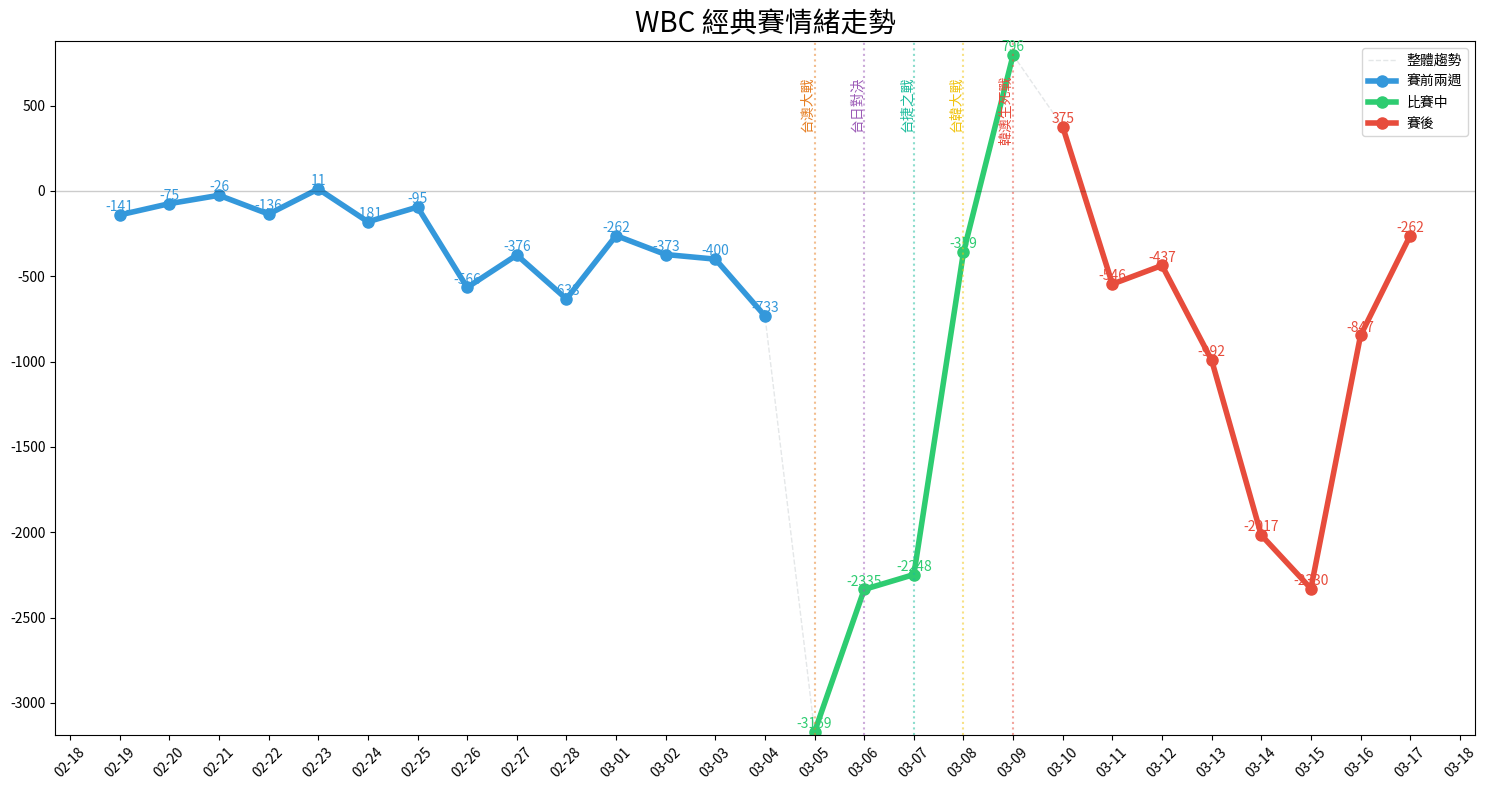

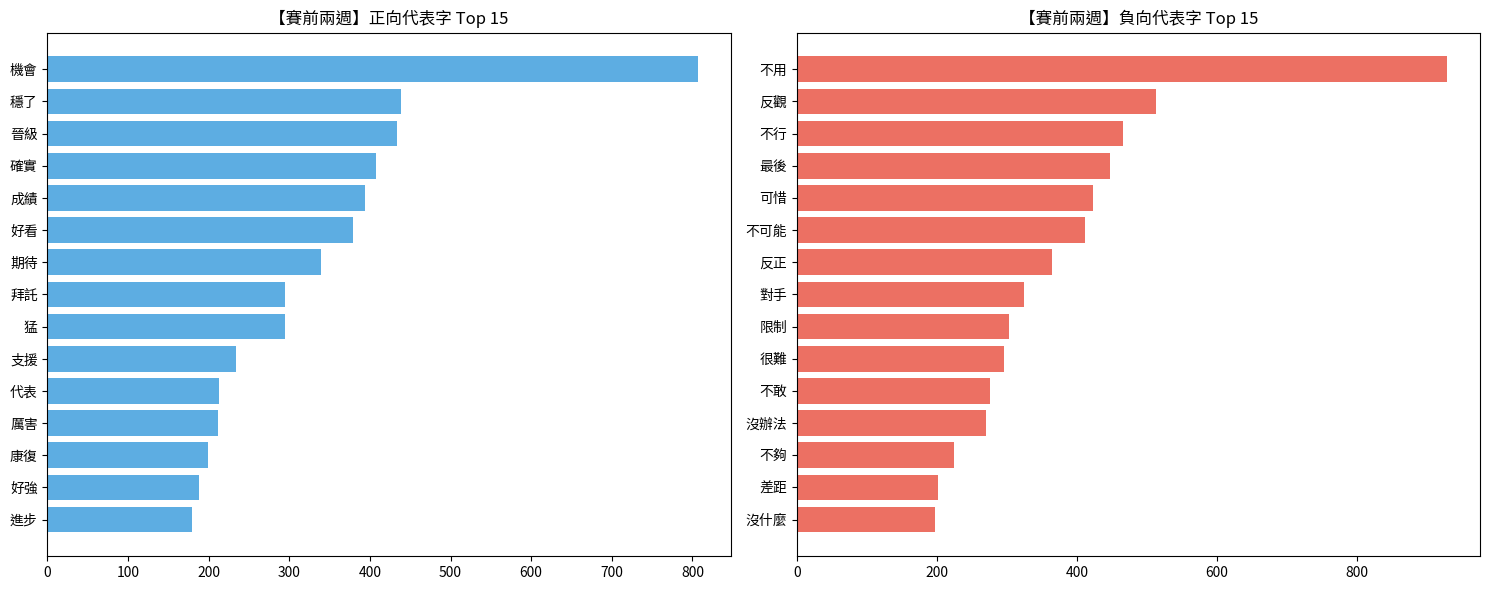

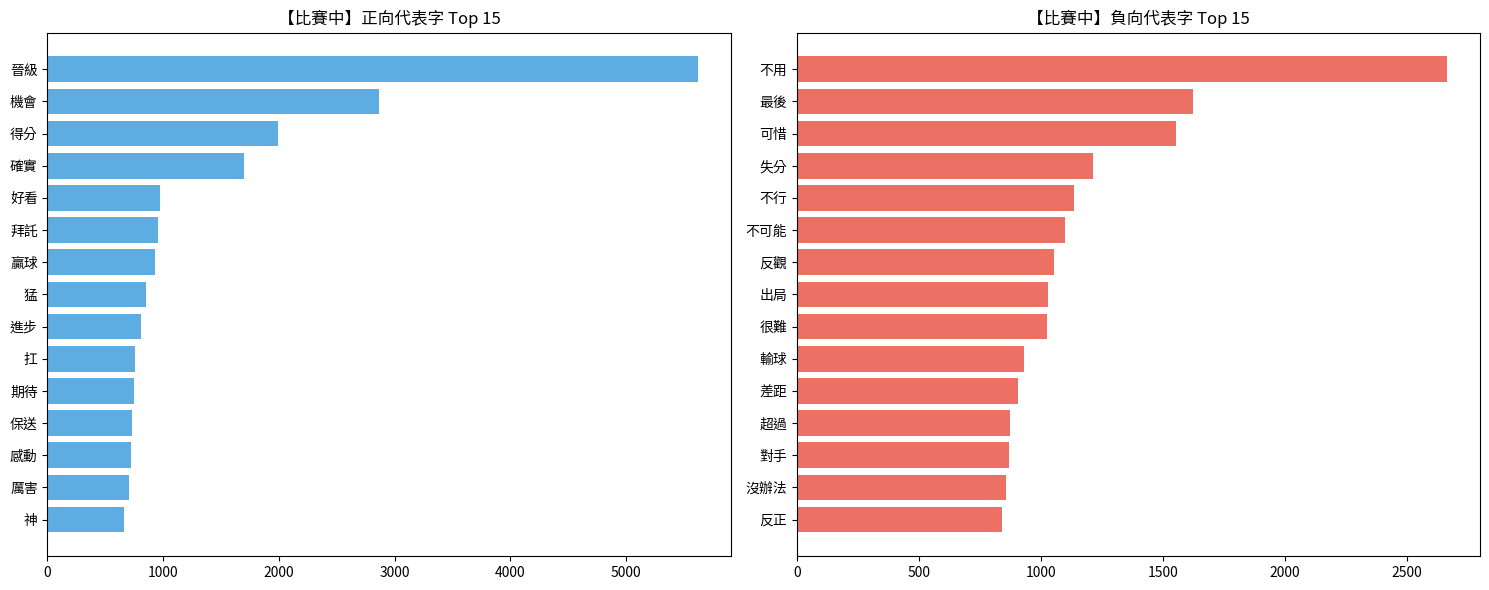

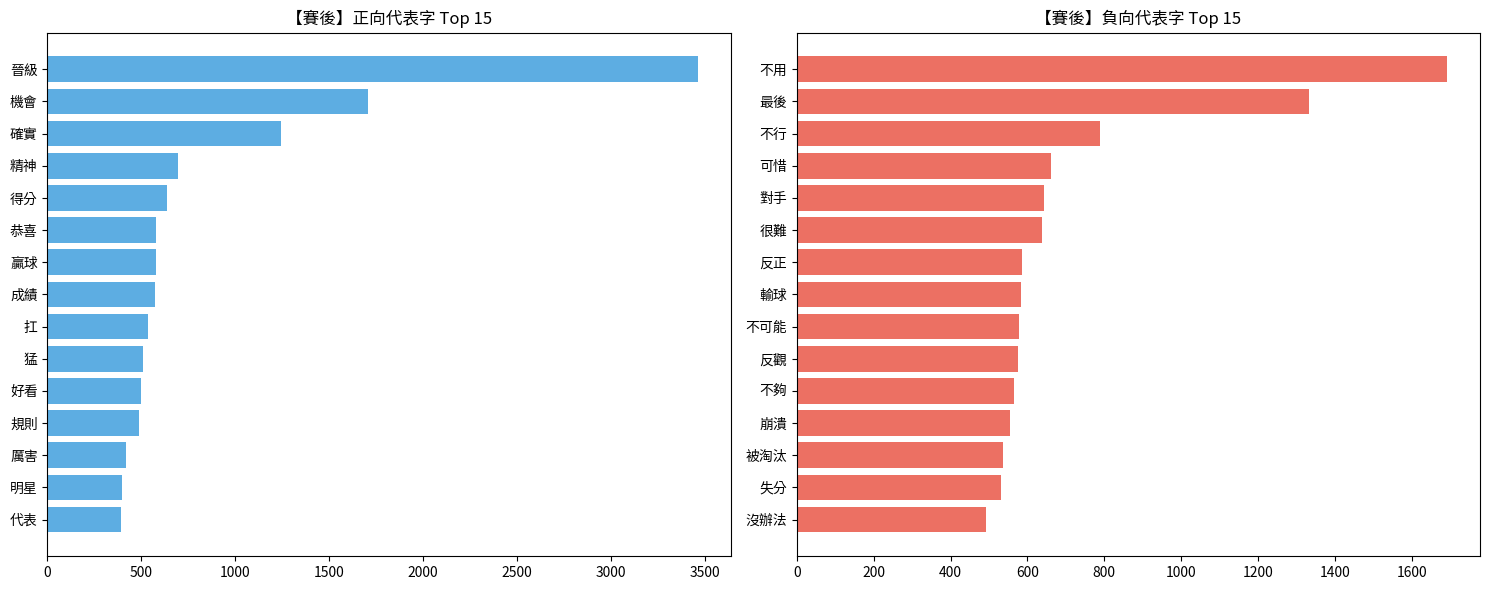


✅ 分析圖表已成功生成，且未更動全域 DATA_SOURCE 設定。


In [77]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.dates as mdates

# ==========================================
# 0. 【卯郁專用】強制指定分析資料來源 (關鍵修改)
# ==========================================
# 這樣做可以確保後續的 clear_df 讀取的是你在 Cell 7 跑出來的 2/19~3/17 資料
# 而不是被智絢在 Cell 5 過濾過的資料。
try:
    clear_df = maoyu_full_comments_df.copy()
    # 這裡我們也要確保 ptt_liwc_df 或後續計算使用的 liwc_dict 是全域可用的
    print(f"✅ 已成功載入『卯郁專用』資料，總筆數：{len(clear_df)}")
except NameError:
    print("❌ 錯誤：找不到 maoyu_full_comments_df，請先執行 Cell 11 的 process_dataframe(df_maoyu_filtered)")

# ==========================================
# 1. 全域路徑與字型註冊 (維持不變)
# ==========================================
BASE_PATH = "/content/drive/MyDrive/中山大學/社群媒體分析/SMA_2024S-main/"
FONT_PATH = BASE_PATH + "week4/SourceHanSansTW-Regular.otf"

if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    prop = fm.FontProperties(fname=FONT_PATH)
    plt.rcParams['font.family'] = prop.get_name()
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✅ 字型載入成功: {prop.get_name()}")
else:
    plt.rcParams['font.family'] = ['Arial Unicode MS', 'sans-serif']

# ==========================================
# 2. 定義時間段與關鍵賽程 (維持不變)
# ==========================================
periods = {
    '賽前兩週': ('2026-02-19', '2026-03-04'),
    '比賽中': ('2026-03-05', '2026-03-09'),
    '賽後': ('2026-03-10', '2026-03-17')
}

key_matches = {
    '2026-03-05': '台澳大戰',
    '2026-03-06': '台日對決',
    '2026-03-07': '台捷之戰',
    '2026-03-08': '台韓大戰',
    '2026-03-09': '韓澳生死戰'
}

# ==========================================
# 3. 核心分析邏輯 (優化：補齊所有日期)
# ==========================================
# 確保日期格式正確
clear_df['date'] = pd.to_datetime(clear_df['artDate']).dt.date

# 斷詞與情緒對照
word_df = clear_df.assign(word=clear_df['processed_text'].astype(str).str.split()).explode('word')
# 這裡使用 merge 結合情緒字典
ptt_liwc_df = pd.merge(word_df, liwc_dict[['word', 'sentiments']], on='word', how='inner')

# 計算每日情緒
sentiment_daily = ptt_liwc_df.groupby(['date', 'sentiments']).size().unstack(fill_value=0)

# 確保欄位存在
for col in ['positive', 'negative']:
    if col not in sentiment_daily.columns:
        sentiment_daily[col] = 0

sentiment_daily["情緒淨分"] = sentiment_daily["positive"] - sentiment_daily["negative"]

# 建立完整日期範圍，確保 X 軸不會因為某天沒資料就跳過
all_period_start = pd.to_datetime(periods['賽前兩週'][0]).date()
all_period_end = pd.to_datetime(periods['賽後'][1]).date()
full_date_range = pd.date_range(all_period_start, all_period_end).date

# 將結果 Reindex 到完整日期，沒資料的填 0
sentiment_daily = sentiment_daily.reindex(full_date_range, fill_value=0)

# ==========================================
# 4. 繪製趨勢比較圖 (維持原繪圖邏輯)
# ==========================================
fig, ax = plt.subplots(figsize=(15, 8))

# 畫出整體背景虛線
ax.plot(sentiment_daily.index, sentiment_daily["情緒淨分"],
        color='#bdc3c7', linewidth=1, linestyle='--', alpha=0.4, label='整體趨勢')

# 依照階段上色
line_colors = {'賽前兩週': '#3498db', '比賽中': '#2ecc71', '賽後': '#e74c3c'}

for p_name, (start_d, end_d) in periods.items():
    s_dt = pd.to_datetime(start_d).date()
    e_dt = pd.to_datetime(end_d).date()
    p_data = sentiment_daily.loc[s_dt:e_dt]

    if not p_data.empty:
        ax.plot(p_data.index, p_data["情緒淨分"],
                label=f'{p_name}', color=line_colors[p_name],
                linewidth=4, marker='o', markersize=8)

        for x, y in zip(p_data.index, p_data["情緒淨分"]):
            if y != 0:
                ax.text(x, y + 5, f'{int(y)}', ha='center', va='bottom',
                        fontsize=10, fontweight='bold', color=line_colors[p_name])

# 優化 Y 軸範圍
ax.set_ylim(sentiment_daily["情緒淨分"].min() - 20, sentiment_daily["情緒淨分"].max() + 80)

# X 軸格式與比賽線條標記
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())

# --- X 軸與比賽標記 (修正文字突出的問題) ---
match_colors = ['#E67E22', '#9B59B6', '#1ABC9C', '#F1C40F', '#E74C3C']
for i, (m_date_str, m_name) in enumerate(key_matches.items()):
    m_date = pd.to_datetime(m_date_str).date()
    ax.axvline(x=m_date, color=match_colors[i%5], linestyle=':', alpha=0.5)

    # 這裡將 y 座標改用 transform=ax.get_xaxis_transform()
    # 這樣 0.95 代表的是「圖表內高度的 95%」，無論數據多大，文字都會乖乖待在框框內
    ax.text(m_date, 0.95, f"{m_name}", transform=ax.get_xaxis_transform(),
            rotation=90, color=match_colors[i%5], ha='right', va='top',
            fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=1, alpha=0.2)
ax.set_title('WBC 經典賽情緒走勢', fontsize=20)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# 5. 繪製情緒代表字 (修正 results 依賴問題)
# ==========================================
# 重新計算各階段的結果，確保不依賴全域的 results 字典
for period_name, (start_d, end_d) in periods.items():
    s_dt = pd.to_datetime(start_d).date()
    e_dt = pd.to_datetime(end_d).date()

    # 篩選該階段的詞彙資料
    p_word_df = ptt_liwc_df[(ptt_liwc_df['date'] >= s_dt) & (ptt_liwc_df['date'] <= e_dt)]

    if len(p_word_df) < 10:
        print(f"⚠️ 跳過【{period_name}】：資料不足 10 筆")
        continue

    # 統計詞頻
    word_counts = p_word_df.groupby(['word', 'sentiments']).size().reset_index(name='count')
    top_pos = word_counts[word_counts["sentiments"] == "positive"].nlargest(15, 'count')
    top_neg = word_counts[word_counts["sentiments"] == "negative"].nlargest(15, 'count')

    # 繪圖
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    if not top_pos.empty:
        ax1.barh(top_pos["word"][::-1], top_pos["count"][::-1], color="#5dade2")
        ax1.set_title(f"【{period_name}】正向代表字 Top 15")

    if not top_neg.empty:
        ax2.barh(top_neg["word"][::-1], top_neg["count"][::-1], color="#ec7063")
        ax2.set_title(f"【{period_name}】負向代表字 Top 15")

    plt.tight_layout()
    plt.show()

print("\n✅ 分析圖表已成功生成，且未更動全域 DATA_SOURCE 設定。")

## (曉君)文字雲_可以放這裡

綜合文字雲分析期間：2026-02-19～2026-03-17
資料筆數： (63592, 13)
展開後詞數： (214497, 14)
符合情緒字典的詞數： (20171, 15)
綜合文字雲 Top 20 詞：


,word,sentiments,count
0,機會,positive,495
1,不用,negative,463
2,得分,positive,406
3,差距,negative,328
4,確實,positive,298
5,保送,positive,274
6,晉級,positive,270
7,可惜,negative,250
8,扛,positive,244
9,進步,positive,218


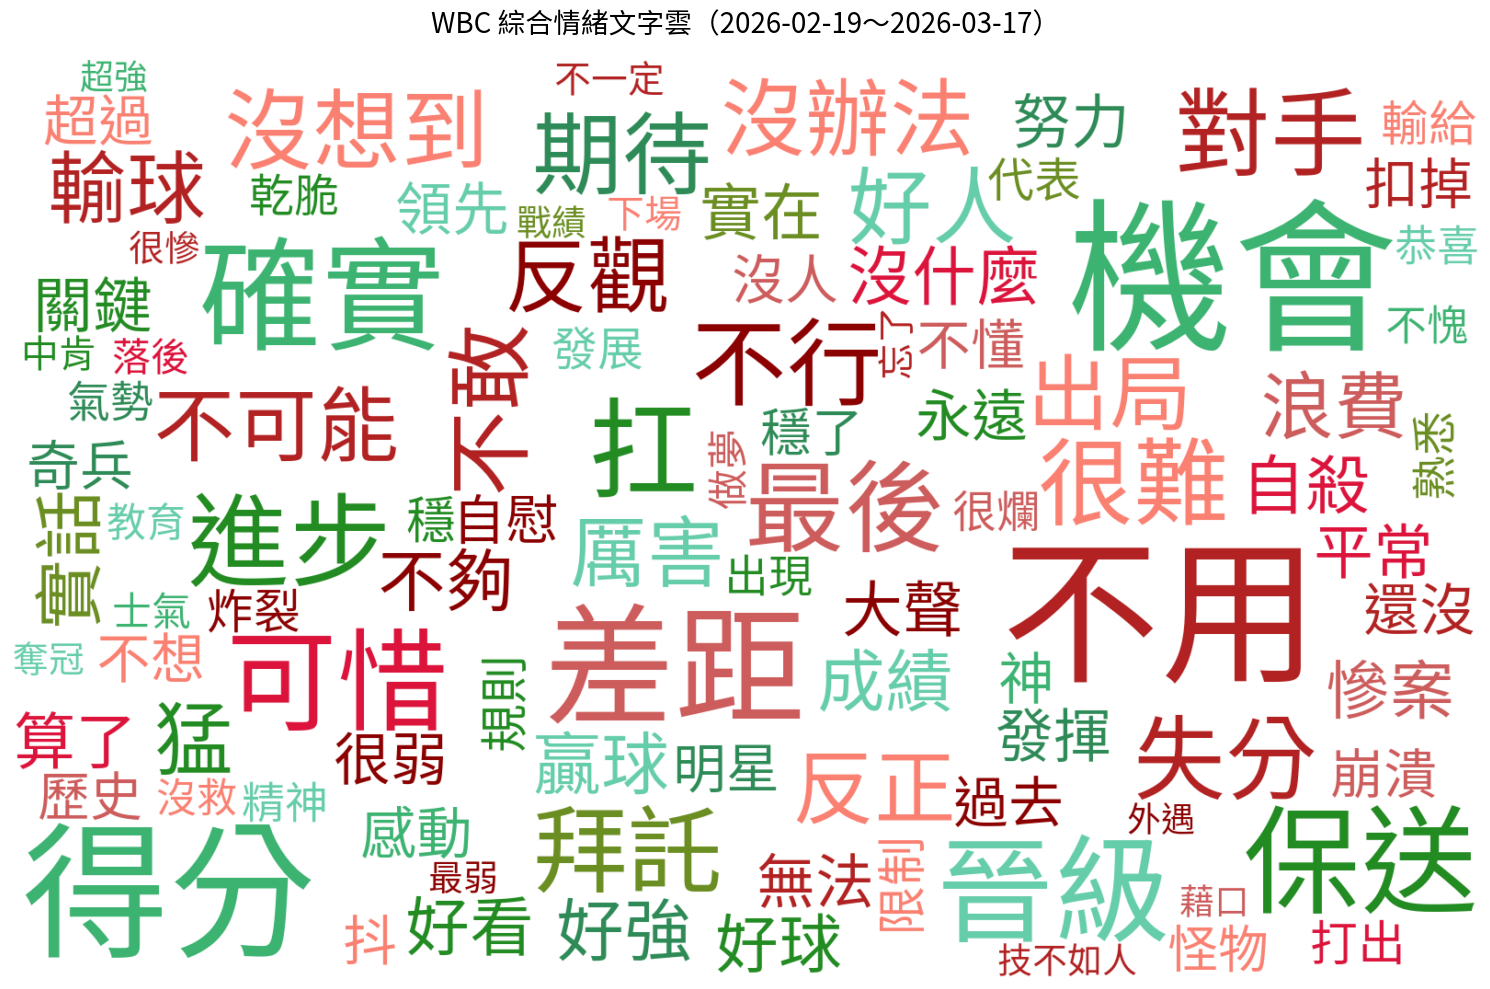

情緒分佈：


,sentiments,count,percentage
0,negative,11383,56.432502
1,positive,8788,43.567498


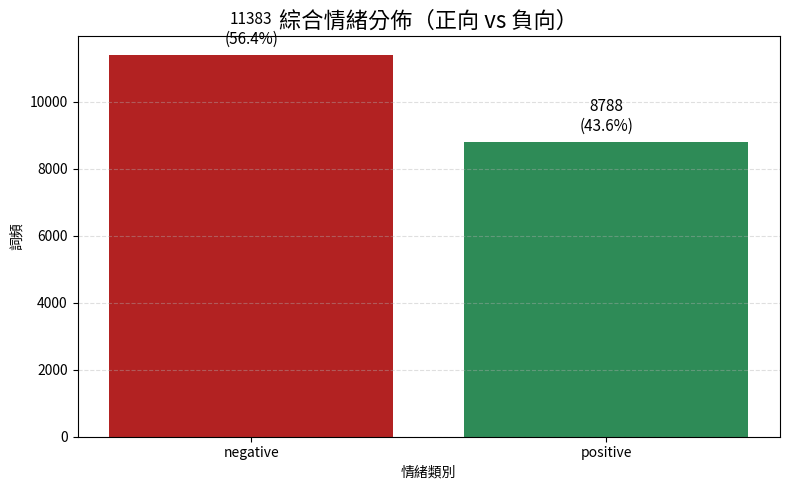

✅ 綜合文字雲與情緒分佈圖已完成


In [74]:
# ==========================================
# 6. 綜合情緒文字雲
#    期間：賽前2026-02-19 ～ 賽後2026-03-17
#    正負向合計後取前200詞
# ==========================================
from wordcloud import WordCloud
import random

# Use maoyu_analysis_df which already has the processed_text column
clear_df = maoyu_analysis_df.copy()

# ---- 確保日期欄位存在 ----
clear_df['date'] = pd.to_datetime(clear_df['artDate'], errors='coerce').dt.date

# ---- 篩選期間 ----
wc_start = pd.to_datetime("2026-02-19").date()
wc_end   = pd.to_datetime("2026-03-17").date()

wc_df = clear_df[
    (clear_df['date'] >= wc_start) &
    (clear_df['date'] <= wc_end)
].copy()

print("綜合文字雲分析期間：2026-02-19～2026-03-17")
print("資料筆數：", wc_df.shape)

# ---- 展開 processed_text 成單字詞 ----
wc_word_df = wc_df.assign(
    word=wc_df['processed_text'].astype(str).str.split()
).explode('word')

wc_word_df['word'] = wc_word_df['word'].astype(str).str.strip()
wc_word_df = wc_word_df[
    (wc_word_df['word'].notna()) &
    (wc_word_df['word'] != "") &
    (wc_word_df['word'] != "nan")
].copy()

print("展開後詞數：", wc_word_df.shape)

# ---- 與情緒字典合併，只保留正負向詞 ----
wc_sentiment_df = pd.merge(
    wc_word_df,
    liwc_dict[['word', 'sentiments']].drop_duplicates(),
    on='word',
    how='inner'
)

wc_sentiment_df = wc_sentiment_df[
    wc_sentiment_df['sentiments'].isin(['positive', 'negative'])
].copy()

print("符合情緒字典的詞數：", wc_sentiment_df.shape)

# ---- 正負向合計後，依整體詞頻取前200 ----
wc_top200 = (
    wc_sentiment_df
    .groupby(['word', 'sentiments'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(100)
    .reset_index(drop=True)
)

print("綜合文字雲 Top 20 詞：")
display(wc_top200.head(20))

# ---- 建立文字雲所需字典 ----
freq_dict = dict(zip(wc_top200['word'], wc_top200['count']))
sentiment_map = dict(zip(wc_top200['word'], wc_top200['sentiments']))

# ---- 情緒顏色函式 ----
def sentiment_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    sentiment = sentiment_map.get(word, 'neutral')
    if sentiment == 'positive':
        return random.choice(["#2E8B57", "#3CB371", "#66CDAA", "#228B22", "#6B8E23"])
    elif sentiment == 'negative':
        return random.choice(["#B22222", "#DC143C", "#CD5C5C", "#8B0000", "#FA8072"])
    else:
        return "#808080"

# ---- 繪製綜合文字雲 ----
if len(freq_dict) == 0:
    print("找不到可繪製文字雲的情緒詞，請確認 processed_text 或 liwc_dict。")
else:
    wc = WordCloud(
        font_path=FONT_PATH if os.path.exists(FONT_PATH) else None,
        width=1600,
        height=1000,
        background_color='white',
        max_words=200,
        prefer_horizontal=0.9,
        collocations=False,
        relative_scaling=0.6,
        min_font_size=10,
        max_font_size=180
    ).generate_from_frequencies(freq_dict)

    wc = wc.recolor(color_func=sentiment_color_func)

    plt.figure(figsize=(18, 10))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("WBC 綜合情緒文字雲（2026-02-19～2026-03-17）", fontsize=20, pad=20)
    plt.tight_layout()
    plt.show()

# ---- 情緒分佈統計 ----
sentiment_counts = (
    wc_sentiment_df['sentiments']
    .value_counts()
    .rename_axis('sentiments')
    .reset_index(name='count')
)

if not sentiment_counts.empty:
    sentiment_counts['percentage'] = sentiment_counts['count'] / sentiment_counts['count'].sum() * 100

    print("情緒分佈：")
    display(sentiment_counts)

    plt.figure(figsize=(8, 5))
    plt.bar(
        sentiment_counts['sentiments'],
        sentiment_counts['count'],
        color=['#2E8B57' if s == 'positive' else '#B22222' for s in sentiment_counts['sentiments']]
    )

    for i, row in sentiment_counts.iterrows():
        plt.text(
            i,
            row['count'] + max(sentiment_counts['count']) * 0.02,
            f"{row['count']}\n({row['percentage']:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=11
        )

    plt.title("綜合情緒分佈（正向 vs 負向）", fontsize=16)
    plt.xlabel("情緒類別")
    plt.ylabel("詞頻")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

print("✅ 綜合文字雲與情緒分佈圖已完成")
